
# Homework

1. Train NN model with custom linear architecture on A-Z Handwritten Alphabet dataset from Kaggle (image data with resolution not higher than 80x80 pixels - A-Z Handwritten Alphabet, etc.)

2. Visualize epoch progress (loss and accuracy curves) *both train and test

3. Visualize 10 random elements from test set and model results 


In [1]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
import torch
from torch import nn

In [2]:
df = pd.read_csv('data\A_Z Handwritten Data.csv')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

No GPU


In [4]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (372450, 785)
Columns: ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']

First few rows:
   0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.639  0.640  0.641  \
0  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.642  0.643  0.644  0.645  0.646  0.647  0.648  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]


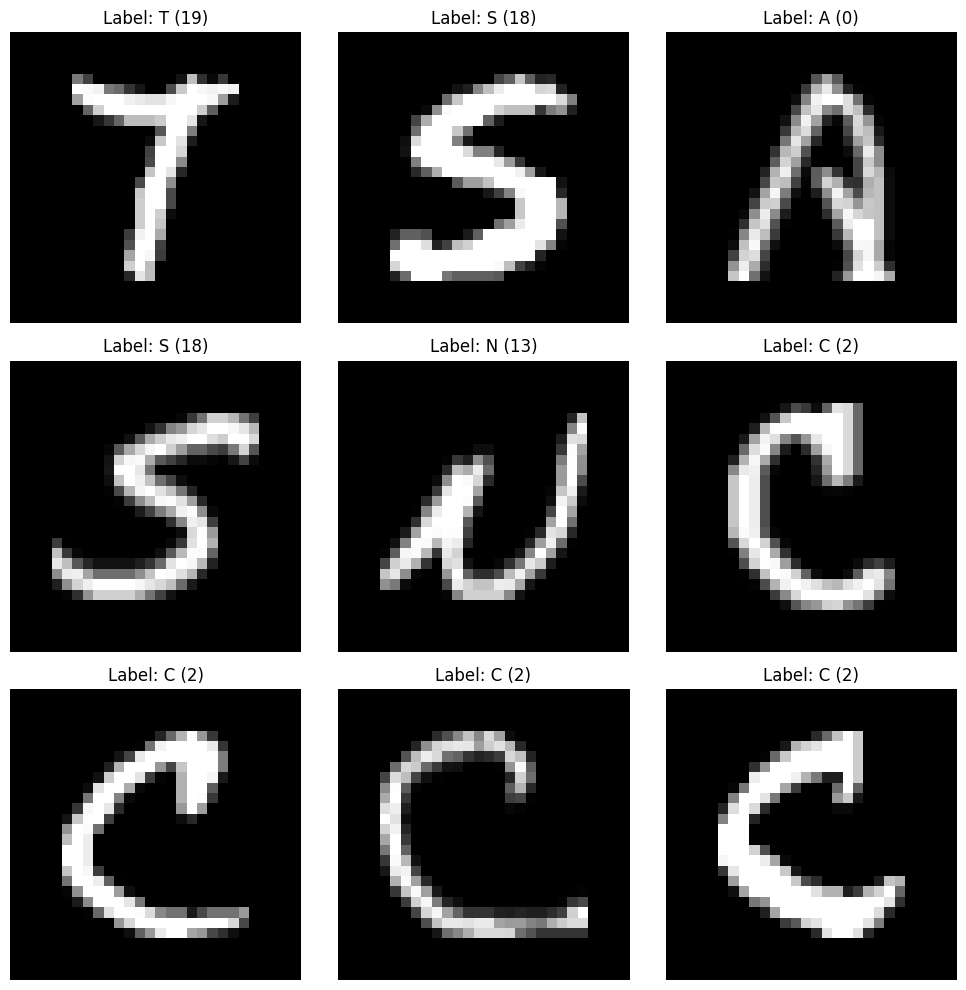

In [5]:
labels = df.iloc[:, 0].values
features = df.iloc[:, 1:].values
img_size = int(np.sqrt(features.shape[1]))

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(features))
    img = features[idx].reshape(img_size, img_size)
    label_idx = int(labels[idx])
    letter = string.ascii_uppercase[label_idx] if label_idx < 26 else str(label_idx)
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {letter} ({label_idx})")
    ax.axis('off')
    
plt.tight_layout()
plt.show()

In [ ]:
class NeuralModel(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, output_size)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
model = NeuralModel(28*28, 26)
print(model)

NeuralModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=26, bias=True)
  )
)


In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42) 

print("X_train and X_test shapes")
X_train.shape, X_test.shape

X_train and X_test shapes


((279337, 784), (93113, 784))

In [14]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32) / 255.0
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32) / 255.0
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Size train dataset: {len(train_dataset)}")
print(f"Size test dataset: {len(test_dataset)}")

Size train dataset: 279337
Size test dataset: 93113


In [9]:
def train_loop(dataloader, model, loss_fn, optimizer, epoch):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    
    train_loss, correct = 0.0, 0
    
    tqdm_loader = tqdm(dataloader, unit="batch", desc=f"Epoch {epoch}", total=len(dataloader))
    for batch, (X, y) in enumerate(tqdm_loader):
        X, y = X.to(device), y.to(device)
        
        pred = model(X)
        loss = loss_fn(pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        
    train_loss /= num_batches
    train_acc = correct / size
    return train_loss, train_acc

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    
    test_loss, correct = 0.0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            
    test_loss /= num_batches
    test_acc = correct / size
    return test_loss, test_acc

In [10]:
learning_rate = 0.001
epochs = 15

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

input_size = 28*28
output_size = 26

In [ ]:
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for t in range(epochs):
    train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer, epoch=t+1)
    test_loss, test_acc = test_loop(test_loader, model, loss_fn)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"Train - Accuracy: {(100*train_acc):>0.1f}%, Loss: {train_loss:>8f}")
    print(f"Test  - Accuracy: {(100*test_acc):>0.1f}%, Loss: {test_loss:>8f}\n")

Epoch 1: 100%|██████████| 2183/2183 [00:10<00:00, 213.95batch/s]


Train - Accuracy: 42.1%, Loss: 2.257539
Test  - Accuracy: 58.7%, Loss: 1.630329



Epoch 2: 100%|██████████| 2183/2183 [00:10<00:00, 216.34batch/s]


Train - Accuracy: 60.8%, Loss: 1.525377
Test  - Accuracy: 69.9%, Loss: 1.210771



Epoch 3: 100%|██████████| 2183/2183 [00:10<00:00, 207.47batch/s]


...

Train - Accuracy: 87.6%, Loss: 0.469676
Test  - Accuracy: 91.9%, Loss: 0.300170



Epoch 14: 100%|██████████| 2183/2183 [00:11<00:00, 192.97batch/s]


Train - Accuracy: 88.0%, Loss: 0.449182
Test  - Accuracy: 92.3%, Loss: 0.283847



Epoch 15: 100%|██████████| 2183/2183 [00:10<00:00, 210.42batch/s]


Train - Accuracy: 88.3%, Loss: 0.432165
Test  - Accuracy: 92.6%, Loss: 0.271024



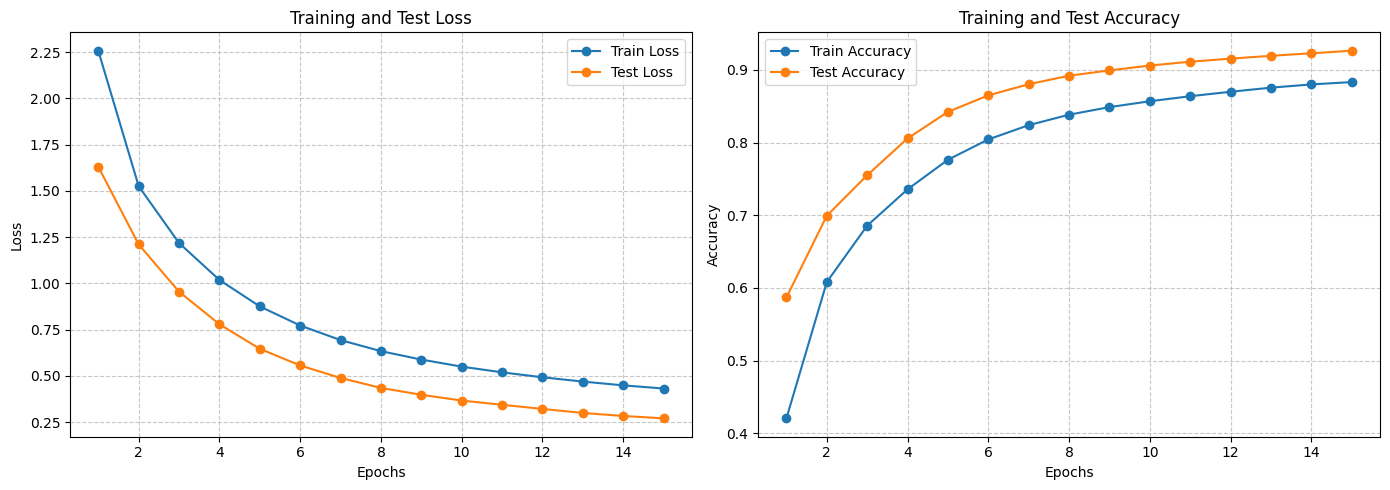

In [12]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, test_losses, label='Test Loss', marker='o')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label='Train Accuracy', marker='o')
plt.plot(epochs_range, test_accs, label='Test Accuracy', marker='o')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

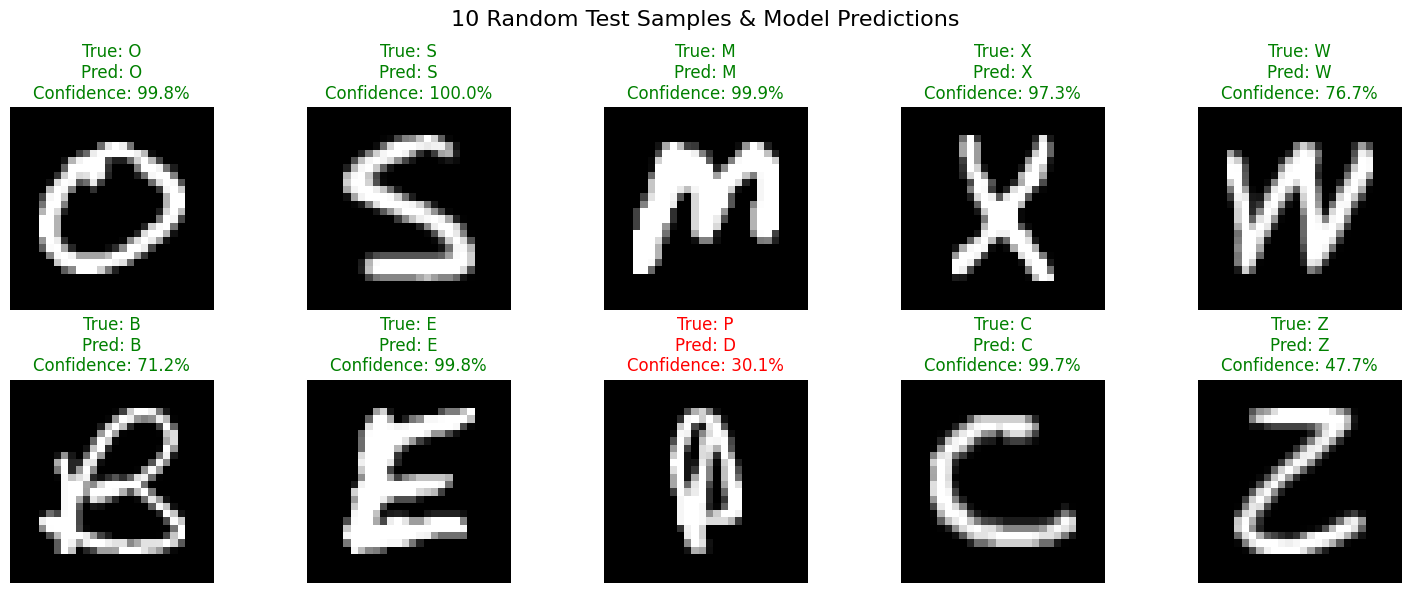

In [17]:
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

indices = np.random.choice(len(test_dataset), 10, replace=False)

with torch.no_grad():
    for i, idx in enumerate(indices):
        ax = axes.flat[i]
        
        X_sample, y_sample_t = test_dataset[idx]
        y_sample = y_sample_t.item()
        
        X_sample_device = X_sample.unsqueeze(0).to(device)
        pred = model(X_sample_device)
        pred_label = pred.argmax(1).item()
        confidence = torch.softmax(pred, dim=1)[0, pred_label].item() * 100
        
        true_letter = string.ascii_uppercase[y_sample] if y_sample < 26 else str(y_sample)
        pred_letter = string.ascii_uppercase[pred_label] if pred_label < 26 else str(pred_label)
        
        img_display = X_sample.numpy().reshape(28, 28)
        ax.imshow(img_display, cmap='gray')
        
        color = 'green' if y_sample == pred_label else 'red'
        ax.set_title(f"True: {true_letter}\nPred: {pred_letter}\nConfidence: {confidence:.1f}%", color=color)
        ax.axis('off')

plt.suptitle("10 Random Test Samples & Model Predictions", fontsize=16)
plt.tight_layout()
plt.show()